# SED Reasoning Dataset Analysis

Comprehensive analysis of the SED reasoning dataset for LLM evaluation. This notebook explores dataset composition, difficulty distribution, generator diversity, and key characteristics that impact puzzle complexity.


In [41]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Professional styling
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('seaborn-whitegrid')
        
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.dpi'] = 100

# Color scheme
COLORS = {
    'easy': '#2ecc71',
    'medium': '#f39c12', 
    'hard': '#e74c3c',
    'expert': '#9b59b6'
}

# Load metadata
data_dir = Path("../data")
with open(data_dir / "metadata.json", "r") as f:
    metadata = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(metadata)

print(f"📊 Dataset Overview")
print(f"{'='*60}")
print(f"Total Problems: {len(df)}")
print(f"Generator Types: {df['generator'].nunique()}")
print(f"Difficulty Levels: {df['difficulty_level'].nunique()}")
print(f"{'='*60}\n")


📊 Dataset Overview
Total Problems: 100
Generator Types: 8
Difficulty Levels: 3



## 1. Dataset Composition

### Difficulty Distribution


/var/folders/1j/6n9mdv5j1zv3pd80zp_xh8mr0000gn/T/ipykernel_89371/503742397.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True,


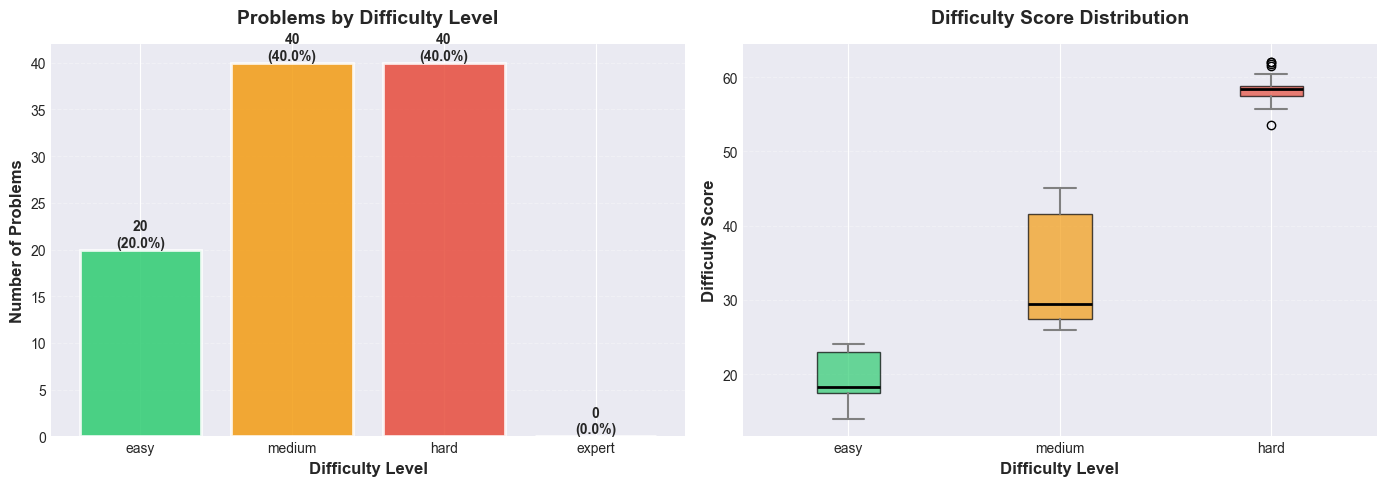


📈 Difficulty Statistics:
Level        Count    %        Mean Score   Score Range
------------------------------------------------------------
Easy         20         20.0%       19.32  14.0-24.0
Medium       40         40.0%       32.58  26.0-45.0
Hard         40         40.0%       58.43  53.5-62.1


In [42]:
# Difficulty distribution
difficulty_counts = df['difficulty_level'].value_counts().reindex(['easy', 'medium', 'hard', 'expert'], fill_value=0)
difficulty_pct = (difficulty_counts / len(df) * 100).round(1)

# Create professional visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot with better styling
colors = [COLORS.get(level, '#95a5a6') for level in difficulty_counts.index]
bars = axes[0].bar(difficulty_counts.index, difficulty_counts.values, color=colors, 
                   edgecolor='white', linewidth=2, alpha=0.85)
axes[0].set_title('Problems by Difficulty Level', fontweight='bold', pad=15)
axes[0].set_xlabel('Difficulty Level', fontweight='bold')
axes[0].set_ylabel('Number of Problems', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# Add value labels on bars
for bar, count, pct in zip(bars, difficulty_counts.values, difficulty_pct.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}\n({pct}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Box plot showing difficulty score distribution
difficulty_order = ['easy', 'medium', 'hard', 'expert']
df_plot = df[df['difficulty_level'].isin(difficulty_order)]
box_data = [df_plot[df_plot['difficulty_level'] == level]['difficulty_score'].values 
            for level in difficulty_order if level in df_plot['difficulty_level'].values]
box_labels = [level for level in difficulty_order if level in df_plot['difficulty_level'].values]

bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True,
                     boxprops=dict(facecolor='white', alpha=0.7),
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(color='gray', linewidth=1.5),
                     capprops=dict(color='gray', linewidth=1.5))

# Color the boxes
for patch, level in zip(bp['boxes'], box_labels):
    patch.set_facecolor(COLORS.get(level, '#95a5a6'))
    patch.set_alpha(0.7)

axes[1].set_title('Difficulty Score Distribution', fontweight='bold', pad=15)
axes[1].set_xlabel('Difficulty Level', fontweight='bold')
axes[1].set_ylabel('Difficulty Score', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n📈 Difficulty Statistics:")
print(f"{'Level':<12} {'Count':<8} {'%':<8} {'Mean Score':<12} {'Score Range'}")
print("-" * 60)
for level in difficulty_order:
    if level in df['difficulty_level'].values:
        subset = df[df['difficulty_level'] == level]
        count = len(subset)
        pct = (count / len(df) * 100)
        mean_score = subset['difficulty_score'].mean()
        score_range = f"{subset['difficulty_score'].min():.1f}-{subset['difficulty_score'].max():.1f}"
        print(f"{level.capitalize():<12} {count:<8} {pct:>6.1f}%  {mean_score:>10.2f}  {score_range}")


### Generator Type Distribution


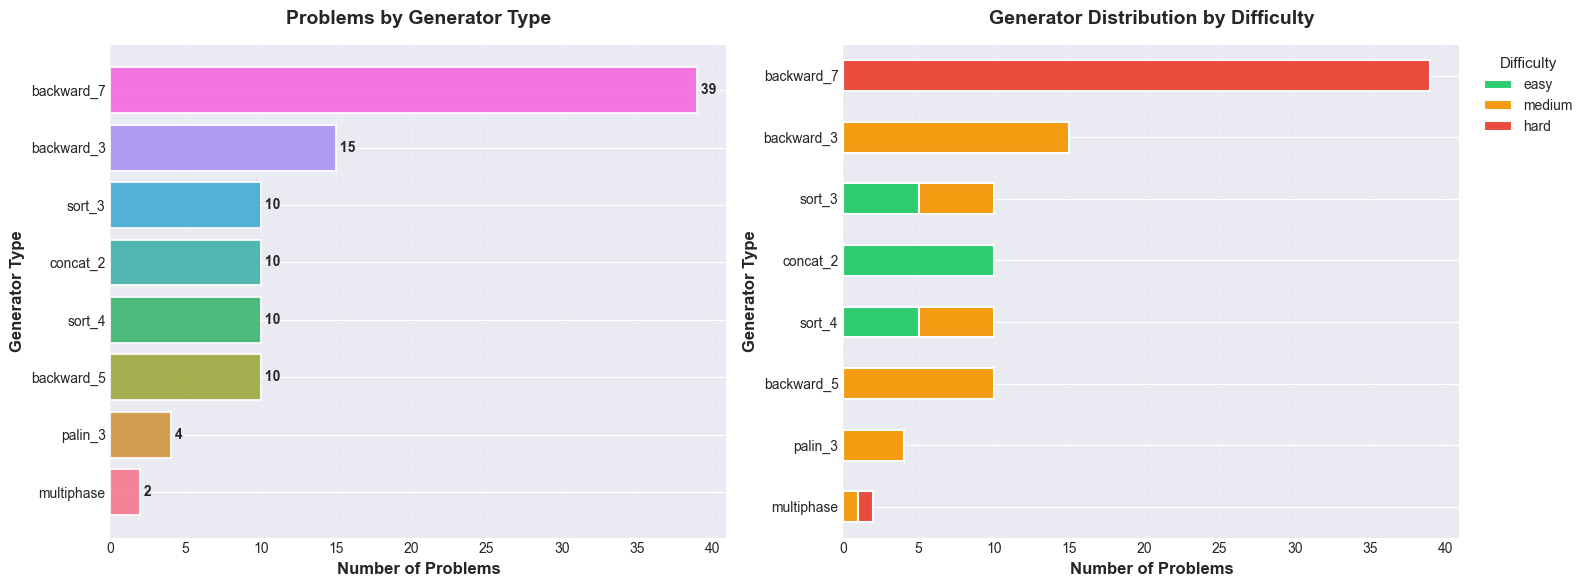


📊 Generator Distribution:
Generator       Count    %        Difficulty Levels
----------------------------------------------------------------------
multiphase      2           2.0%  medium, hard
palin_3         4           4.0%  medium
backward_5      10         10.0%  medium
sort_4          10         10.0%  easy, medium
concat_2        10         10.0%  easy
sort_3          10         10.0%  easy, medium
backward_3      15         15.0%  medium
backward_7      39         39.0%  hard


In [43]:
# Generator distribution
generator_counts = df['generator'].value_counts().sort_values(ascending=True)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar plot (better for long labels)
colors_bar = sns.color_palette("husl", len(generator_counts))
bars = axes[0].barh(generator_counts.index, generator_counts.values, 
                    color=colors_bar, edgecolor='white', linewidth=1.5, alpha=0.85)
axes[0].set_title('Problems by Generator Type', fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Problems', fontweight='bold')
axes[0].set_ylabel('Generator Type', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# Add value labels
for i, (idx, val) in enumerate(generator_counts.items()):
    axes[0].text(val, i, f' {int(val)}', va='center', fontweight='bold', fontsize=10)

# Stacked bar showing difficulty breakdown
generator_difficulty = pd.crosstab(df['generator'], df['difficulty_level'])
generator_difficulty = generator_difficulty.reindex(generator_counts.index)
difficulty_order_plot = [d for d in ['easy', 'medium', 'hard', 'expert'] if d in generator_difficulty.columns]

colors_stack = [COLORS.get(d, '#95a5a6') for d in difficulty_order_plot]
generator_difficulty[difficulty_order_plot].plot(kind='barh', stacked=True, ax=axes[1],
                                                  color=colors_stack, edgecolor='white', linewidth=1.5)
axes[1].set_title('Generator Distribution by Difficulty', fontweight='bold', pad=15)
axes[1].set_xlabel('Number of Problems', fontweight='bold')
axes[1].set_ylabel('Generator Type', fontweight='bold')
axes[1].legend(title='Difficulty', title_fontsize=11, fontsize=10, 
               bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

# Summary
print("\n📊 Generator Distribution:")
print(f"{'Generator':<15} {'Count':<8} {'%':<8} {'Difficulty Levels'}")
print("-" * 70)
for gen in generator_counts.index:
    count = generator_counts[gen]
    pct = (count / len(df) * 100)
    difficulties = ', '.join(df[df['generator'] == gen]['difficulty_level'].unique())
    print(f"{gen:<15} {count:<8} {pct:>6.1f}%  {difficulties}")


## 2. Puzzle Complexity Analysis

### Solution Length vs Difficulty


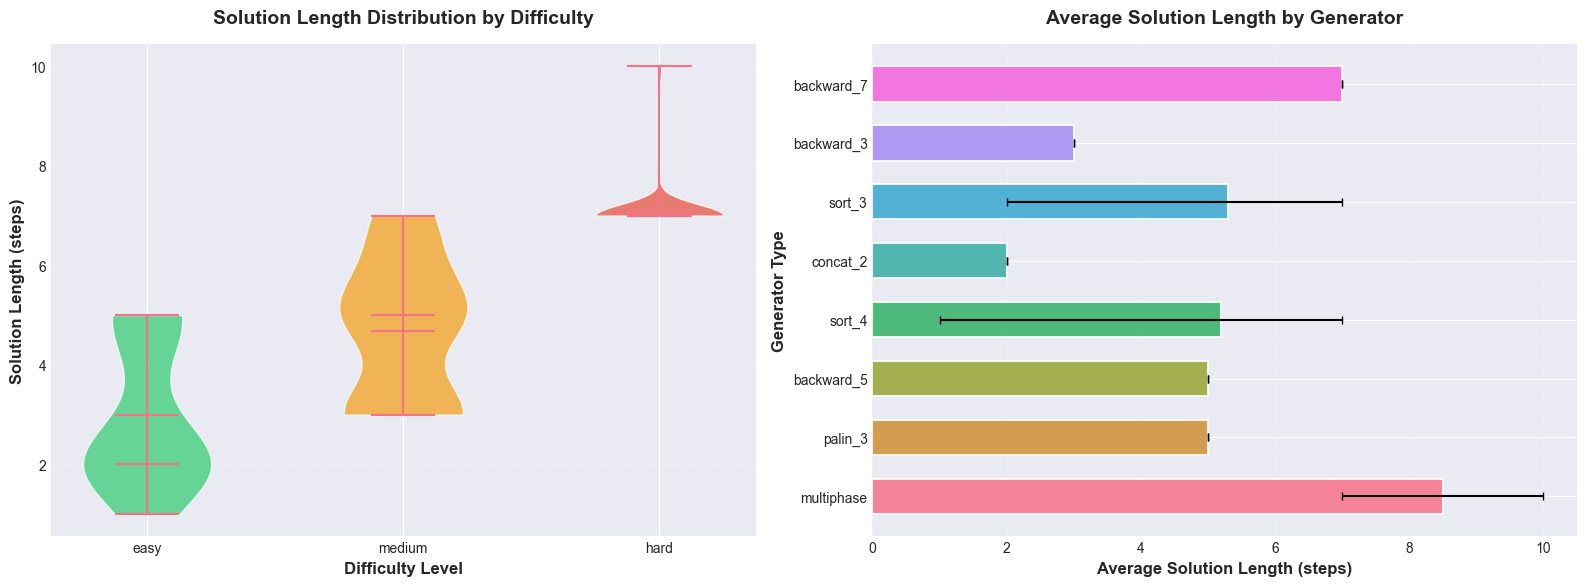


💡 Key Insight:
Solution length increases with difficulty:
  Easy: 3.0 steps on average
  Medium: 4.7 steps on average
  Hard: 7.1 steps on average


In [44]:
# Solution length analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot showing distribution by difficulty
difficulty_order_plot = [d for d in ['easy', 'medium', 'hard', 'expert'] if d in df['difficulty_level'].values]
data_for_violin = [df[df['difficulty_level'] == level]['solution_length'].values 
                   for level in difficulty_order_plot]

parts = axes[0].violinplot(data_for_violin, positions=range(len(difficulty_order_plot)),
                           showmeans=True, showmedians=True)
axes[0].set_xticks(range(len(difficulty_order_plot)))
axes[0].set_xticklabels(difficulty_order_plot)
axes[0].set_title('Solution Length Distribution by Difficulty', fontweight='bold', pad=15)
axes[0].set_xlabel('Difficulty Level', fontweight='bold')
axes[0].set_ylabel('Solution Length (steps)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# Color the violins
for i, (pc, level) in enumerate(zip(parts['bodies'], difficulty_order_plot)):
    pc.set_facecolor(COLORS.get(level, '#95a5a6'))
    pc.set_alpha(0.7)

# Solution length by generator
generator_sol = df.groupby('generator')['solution_length'].agg(['mean', 'min', 'max']).round(1)
generator_sol = generator_sol.reindex(generator_counts.index)

x_pos = np.arange(len(generator_sol))
width = 0.6
bars = axes[1].barh(x_pos, generator_sol['mean'], width, 
                    color=colors_bar, edgecolor='white', linewidth=1.5, alpha=0.85)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(generator_sol.index)
axes[1].set_title('Average Solution Length by Generator', fontweight='bold', pad=15)
axes[1].set_xlabel('Average Solution Length (steps)', fontweight='bold')
axes[1].set_ylabel('Generator Type', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

# Add error bars showing range
for i, (idx, row) in enumerate(generator_sol.iterrows()):
    axes[1].errorbar(row['mean'], i, xerr=[[row['mean'] - row['min']], [row['max'] - row['mean']]],
                    fmt='none', color='black', linewidth=1.5, capsize=3)

plt.tight_layout()
plt.show()

# Key insight
print("\n💡 Key Insight:")
corr_sol_diff = df.groupby('difficulty_level')['solution_length'].mean()
print(f"Solution length increases with difficulty:")
for level in ['easy', 'medium', 'hard', 'expert']:
    if level in corr_sol_diff.index:
        print(f"  {level.capitalize()}: {corr_sol_diff[level]:.1f} steps on average")


### Complexity Relationships


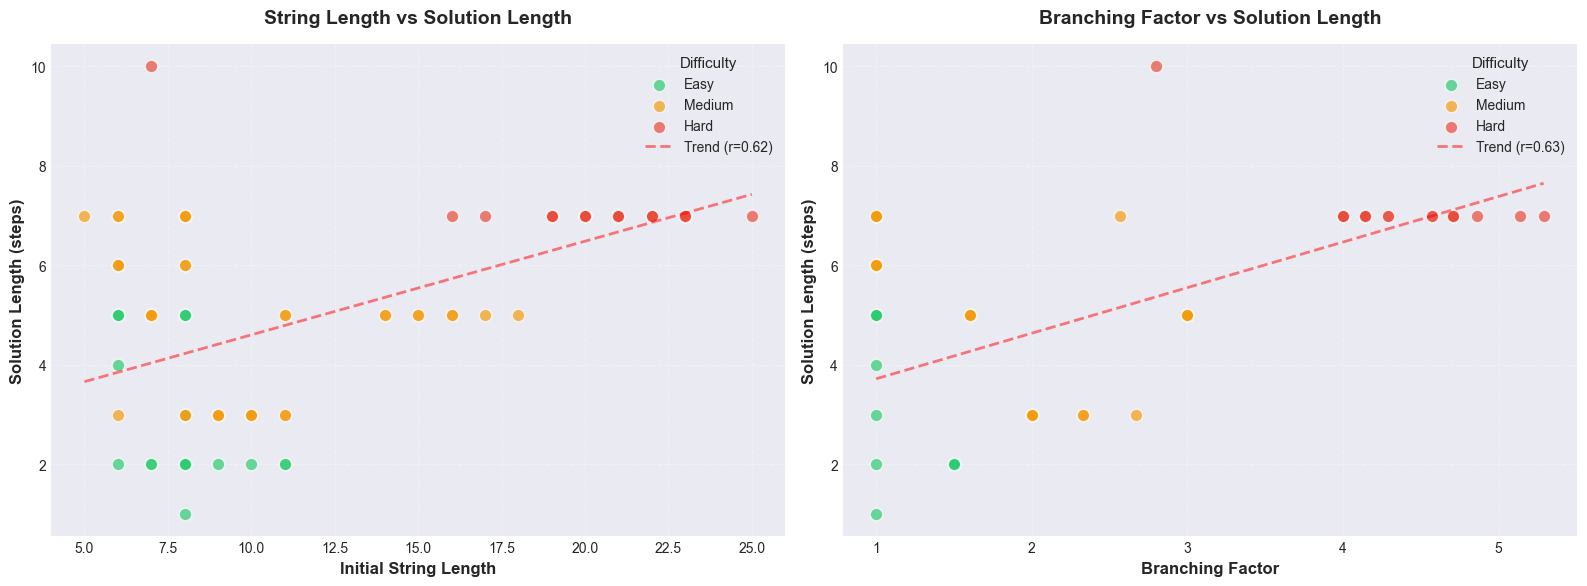


📊 Key Correlations:
  String Length ↔ Solution Length: 0.618
  Branching Factor ↔ Solution Length: 0.627
  String Length ↔ Branching Factor: 0.918


In [45]:
# Correlation analysis and scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: String Length vs Solution Length (colored by difficulty)
for difficulty in ['easy', 'medium', 'hard', 'expert']:
    if difficulty in df['difficulty_level'].values:
        subset = df[df['difficulty_level'] == difficulty]
        axes[0].scatter(subset['string_length'], subset['solution_length'],
                       label=difficulty.capitalize(), alpha=0.7, s=80,
                       color=COLORS.get(difficulty, '#95a5a6'), edgecolors='white', linewidth=1)

# Add trend line
z = np.polyfit(df['string_length'], df['solution_length'], 1)
p = np.poly1d(z)
axes[0].plot(df['string_length'].sort_values(), p(df['string_length'].sort_values()),
            "r--", alpha=0.5, linewidth=2, label=f'Trend (r={df["string_length"].corr(df["solution_length"]):.2f})')

axes[0].set_title('String Length vs Solution Length', fontweight='bold', pad=15)
axes[0].set_xlabel('Initial String Length', fontweight='bold')
axes[0].set_ylabel('Solution Length (steps)', fontweight='bold')
axes[0].legend(title='Difficulty', title_fontsize=11, fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# Scatter: Branching Factor vs Solution Length
for difficulty in ['easy', 'medium', 'hard', 'expert']:
    if difficulty in df['difficulty_level'].values:
        subset = df[df['difficulty_level'] == difficulty]
        axes[1].scatter(subset['branching_factor'], subset['solution_length'],
                       label=difficulty.capitalize(), alpha=0.7, s=80,
                       color=COLORS.get(difficulty, '#95a5a6'), edgecolors='white', linewidth=1)

# Add trend line
z2 = np.polyfit(df['branching_factor'], df['solution_length'], 1)
p2 = np.poly1d(z2)
axes[1].plot(df['branching_factor'].sort_values(), p2(df['branching_factor'].sort_values()),
            "r--", alpha=0.5, linewidth=2, 
            label=f'Trend (r={df["branching_factor"].corr(df["solution_length"]):.2f})')

axes[1].set_title('Branching Factor vs Solution Length', fontweight='bold', pad=15)
axes[1].set_xlabel('Branching Factor', fontweight='bold')
axes[1].set_ylabel('Solution Length (steps)', fontweight='bold')
axes[1].legend(title='Difficulty', title_fontsize=11, fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

# Correlation summary
print("\n📊 Key Correlations:")
corr_str_sol = df['string_length'].corr(df['solution_length'])
corr_br_sol = df['branching_factor'].corr(df['solution_length'])
corr_str_br = df['string_length'].corr(df['branching_factor'])
print(f"  String Length ↔ Solution Length: {corr_str_sol:.3f}")
print(f"  Branching Factor ↔ Solution Length: {corr_br_sol:.3f}")
print(f"  String Length ↔ Branching Factor: {corr_str_br:.3f}")


## 3. Feature Correlation Analysis


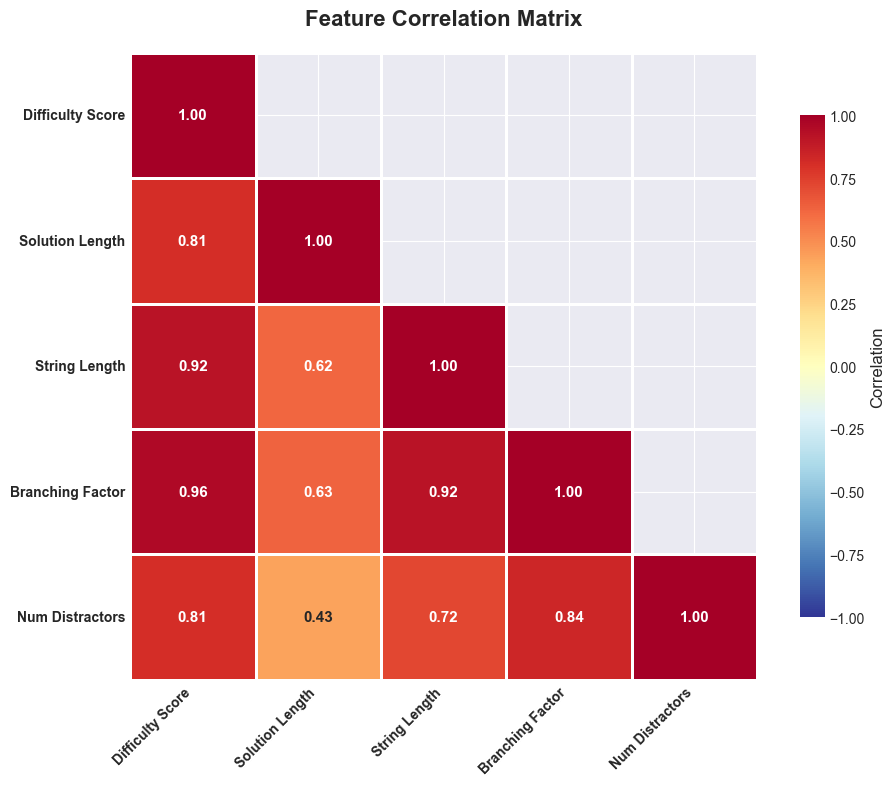


💡 Key Insights:
  • Difficulty score strongly correlates with:
    - Branching factor (r=0.96)
    - String length (r=0.92)
    - Solution length (r=0.81)
  • Solution length moderately correlates with string length (r=0.62)
  • Distractors correlate with difficulty (r=0.81)


In [46]:
# Correlation matrix
numeric_cols = ['difficulty_score', 'solution_length', 'string_length', 
                'branching_factor', 'num_distractors']
correlation_matrix = df[numeric_cols].corr()

# Professional heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)  # Mask upper triangle

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8, "label": "Correlation"},
            mask=mask, vmin=-1, vmax=1, ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})

ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=20, fontsize=16)
ax.set_xticklabels([col.replace('_', ' ').title() for col in correlation_matrix.columns], 
                   rotation=45, ha='right', fontweight='bold')
ax.set_yticklabels([col.replace('_', ' ').title() for col in correlation_matrix.columns],
                   rotation=0, fontweight='bold')

plt.tight_layout()
plt.show()

# Key insights
print("\n💡 Key Insights:")
print(f"  • Difficulty score strongly correlates with:")
print(f"    - Branching factor (r={correlation_matrix.loc['difficulty_score', 'branching_factor']:.2f})")
print(f"    - String length (r={correlation_matrix.loc['difficulty_score', 'string_length']:.2f})")
print(f"    - Solution length (r={correlation_matrix.loc['difficulty_score', 'solution_length']:.2f})")
print(f"  • Solution length moderately correlates with string length (r={correlation_matrix.loc['solution_length', 'string_length']:.2f})")
print(f"  • Distractors correlate with difficulty (r={correlation_matrix.loc['difficulty_score', 'num_distractors']:.2f})")


## 4. Dataset Summary & Insights


In [47]:
# Comprehensive summary
generator_counts_summary = df['generator'].value_counts().sort_values(ascending=False)

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"\n📊 Basic Statistics:")
print(f"  Total Problems: {len(df)}")
print(f"  Generator Types: {df['generator'].nunique()}")
print(f"  Difficulty Levels: {df['difficulty_level'].nunique()}")

print(f"\n📈 Difficulty Distribution:")
for level in ['easy', 'medium', 'hard', 'expert']:
    if level in df['difficulty_level'].values:
        count = len(df[df['difficulty_level'] == level])
        pct = count / len(df) * 100
        mean_score = df[df['difficulty_level'] == level]['difficulty_score'].mean()
        print(f"  {level.capitalize():<8}: {count:>3} puzzles ({pct:>5.1f}%) | Avg score: {mean_score:.1f}")

print(f"\n🔧 Generator Distribution:")
for gen in generator_counts_summary.index:
    count = generator_counts_summary[gen]
    pct = (count / len(df) * 100)
    avg_sol = df[df['generator'] == gen]['solution_length'].mean()
    print(f"  {gen:<15}: {count:>3} puzzles ({pct:>5.1f}%) | Avg solution: {avg_sol:.1f} steps")

print(f"\n📏 Complexity Metrics:")
print(f"  Solution Length: {df['solution_length'].min()}-{df['solution_length'].max()} steps (mean: {df['solution_length'].mean():.1f})")
print(f"  String Length: {df['string_length'].min()}-{df['string_length'].max()} chars (mean: {df['string_length'].mean():.1f})")
print(f"  Branching Factor: {df['branching_factor'].min():.2f}-{df['branching_factor'].max():.2f} (mean: {df['branching_factor'].mean():.2f})")
print(f"  Problems with Distractors: {(df['num_distractors'] > 0).sum()} ({(df['num_distractors'] > 0).sum()/len(df)*100:.1f}%)")

print(f"\n💡 Key Insights for LLM Evaluation:")
print(f"  1. Well-balanced difficulty distribution")
print(f"  2. Diverse generator types covering different reasoning patterns:")
print(f"     • Sequential reasoning (backward_3/5/7)")
print(f"     • Algorithmic reasoning (sort_3/4)")
print(f"     • Multi-phase reasoning (multiphase)")
print(f"     • Pattern recognition (palin_3, concat_2)")
print(f"  3. Strong correlation between difficulty and complexity metrics")
print(f"  4. {((df['num_distractors'] > 0).sum()/len(df)*100):.0f}% of puzzles include distractors (tests reasoning vs pattern matching)")
print(f"  5. Solution length range ({df['solution_length'].min()}-{df['solution_length'].max()} steps) suitable for CoT evaluation")

print("=" * 70)


DATASET SUMMARY

📊 Basic Statistics:
  Total Problems: 100
  Generator Types: 8
  Difficulty Levels: 3

📈 Difficulty Distribution:
  Easy    :  20 puzzles ( 20.0%) | Avg score: 19.3
  Medium  :  40 puzzles ( 40.0%) | Avg score: 32.6
  Hard    :  40 puzzles ( 40.0%) | Avg score: 58.4

🔧 Generator Distribution:
  backward_7     :  39 puzzles ( 39.0%) | Avg solution: 7.0 steps
  backward_3     :  15 puzzles ( 15.0%) | Avg solution: 3.0 steps
  backward_5     :  10 puzzles ( 10.0%) | Avg solution: 5.0 steps
  sort_4         :  10 puzzles ( 10.0%) | Avg solution: 5.2 steps
  concat_2       :  10 puzzles ( 10.0%) | Avg solution: 2.0 steps
  sort_3         :  10 puzzles ( 10.0%) | Avg solution: 5.3 steps
  palin_3        :   4 puzzles (  4.0%) | Avg solution: 5.0 steps
  multiphase     :   2 puzzles (  2.0%) | Avg solution: 8.5 steps

📏 Complexity Metrics:
  Solution Length: 1-10 steps (mean: 5.3)
  String Length: 5-25 chars (mean: 13.7)
  Branching Factor: 1.00-5.29 (mean: 2.73)
  Problems w